In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# dataset path
BASE = '/kaggle/input'
DATASET_PATH = None
for root, dirs, files in os.walk(BASE):
    if 'train' in dirs and 'test' in dirs and 'val' in dirs:
        DATASET_PATH = root
        break

assert DATASET_PATH, ' Dataset not found. Check your Kaggle dataset path.'
print(f' Dataset found at: {DATASET_PATH}')

TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
VAL_DIR   = os.path.join(DATASET_PATH, 'val')
TEST_DIR  = os.path.join(DATASET_PATH, 'test')
CLASSES   = ['NORMAL', 'PNEUMONIA']

 Dataset found at: /kaggle/input/datasets/alishoaibvirk/resnet/chest_xray


In [4]:
print('\n' + '='*52)
print('         IMAGE COUNT PER CLASS')
print('='*52)
print(f"{'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-'*52)
for cls in CLASSES:
    tr = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    vl = len(os.listdir(os.path.join(VAL_DIR,   cls)))
    te = len(os.listdir(os.path.join(TEST_DIR,  cls)))
    print(f'{cls:<15} {tr:>8} {vl:>8} {te:>8}')
print('='*52)
print('\n My Kaggle val set has only 16 images (8 per class).')
print('   So im merge train+val and re-split 80/20 for a reliable validation set.')


         IMAGE COUNT PER CLASS
Class              Train      Val     Test
----------------------------------------------------
NORMAL              1341        8      234
PNEUMONIA           3875        8      390

 My Kaggle val set has only 16 images (8 per class).
   So im merge train+val and re-split 80/20 for a reliable validation set.


In [4]:
# ── STEP 3: TRANSFORMS ──────────────────────────────────────


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # grayscale → 3ch for ResNet
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),   # simulate different X-ray exposures
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [5]:

all_train_paths = datasets.ImageFolder(TRAIN_DIR).samples
all_val_paths   = datasets.ImageFolder(VAL_DIR).samples
all_paths       = all_train_paths + all_val_paths
random.Random(SEED).shuffle(all_paths)

split_idx = int(0.80 * len(all_paths))
train_paths = all_paths[:split_idx]
val_paths   = all_paths[split_idx:]

class XRayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = XRayDataset(train_paths, transform=train_transform)
val_dataset   = XRayDataset(val_paths,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}  ← now reliable!')
print(f'Test samples  : {len(test_dataset)}')

Train samples : 4185
Val samples   : 1047  ← now reliable!
Test samples  : 624


In [6]:
train_labels = [label for _, label in train_paths]
class_counts = Counter(train_labels)
total_samples = sum(class_counts.values())

# Weight = total / (num_classes * count_of_class)
class_weights = torch.tensor(
    [total_samples / (2 * class_counts[i]) for i in range(2)],
    dtype=torch.float
).to(device)

print(f'Class counts  → NORMAL: {class_counts[0]}, PNEUMONIA: {class_counts[1]}')
print(f'Class weights → NORMAL: {class_weights[0]:.3f}, PNEUMONIA: {class_weights[1]:.3f}')

Class counts  → NORMAL: 1080, PNEUMONIA: 3105
Class weights → NORMAL: 1.938, PNEUMONIA: 0.674


In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)


imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}')   

Batch shape: torch.Size([32, 3, 224, 224])


In [8]:
class XRayResNet(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super().__init__()

        
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features   

       
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  

        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),   
            nn.Linear(128, num_classes)
        )

    def freeze_backbone(self):
        """Phase 1: only train the classifier head."""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_top_layers(self, num_blocks=2):
        """Phase 2: unfreeze the last N ResNet blocks for fine-tuning."""
        
        children = list(self.backbone.children())
        for child in children[-num_blocks:]:
            for param in child.parameters():
                param.requires_grad = True

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


model = XRayResNet(num_classes=2, dropout_rate=0.5).to(device)
model.freeze_backbone()   

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} (Phase 1 — head only)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Trainable params: 165,250 / 11,341,762 (Phase 1 — head only)


In [9]:
#OPTIMIZERS
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam WITH weight_decay (L2 regularisation) 
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS         = 30
WARMUP_EPOCHS  = 5    

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)

print(f'Phase 1 ({WARMUP_EPOCHS} epochs): train head only with lr=1e-3')
print(f'Phase 2 ({EPOCHS-WARMUP_EPOCHS} epochs): fine-tune top layers with cosine LR decay')

Phase 1 (5 epochs): train head only with lr=1e-3
Phase 2 (25 epochs): fine-tune top layers with cosine LR decay


In [11]:
#EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4, path='best_model.pth'):
        self.patience  = patience
        self.delta     = delta
        self.path      = path
        self.best_loss = float('inf')
        self.counter   = 0
        self.stopped   = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            print(f'     Best model saved (val_loss={val_loss:.4f})')
        else:
            self.counter += 1
            print(f'    ⏳ EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stopped = True
                print('     Early stopping triggered!')

os.makedirs('checkpoints', exist_ok=True)
early_stop = EarlyStopping(patience=7, path='checkpoints/best_model.pth')

In [12]:
#  TRAINING LOOP 

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):

    
    if epoch == WARMUP_EPOCHS + 1:
        print('\n Phase 2: Unfreezing top ResNet layers for fine-tuning...')
        model.unfreeze_top_layers(num_blocks=2)
        # Lower LR for fine-tuning to avoid catastrophic forgetting
        for pg in optimizer.param_groups:
            pg['lr'] = 1e-4
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'   Trainable params: {trainable:,}\n')

    # TRAIN 
    model.train()
    running_loss, correct = 0.0, 0

    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss   = criterion(output, labels)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    trn_loss = running_loss / len(train_loader)
    trn_acc  = 100 * correct / len(train_dataset)

    #validation
    model.eval()
    running_loss, correct = 0.0, 0

    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            loss   = criterion(output, labels)
            running_loss += loss.item()
            correct += (output.argmax(1) == labels).sum().item()

    vl_loss = running_loss / len(val_loader)
    vl_acc  = 100 * correct / len(val_dataset)

    history['train_loss'].append(trn_loss)
    history['train_acc'].append(trn_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    gap = trn_acc - vl_acc
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {trn_loss:.4f} Acc: {trn_acc:.2f}% | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.2f}% | '
          f'Gap: {gap:.2f}%')

    # Early stopping 
    if epoch > WARMUP_EPOCHS:
        early_stop(vl_loss, model)
        if early_stop.stopped:
            print(f'\nTraining stopped early at epoch {epoch}.')
            break
        if epoch > WARMUP_EPOCHS:
            scheduler.step()

print('\n✅ Training complete!')

Epoch 01/30 | Train Loss: 0.3358 Acc: 84.97% | Val Loss: 0.2583 Acc: 86.34% | Gap: -1.37%
Epoch 02/30 | Train Loss: 0.2710 Acc: 88.91% | Val Loss: 0.2450 Acc: 86.63% | Gap: 2.28%
Epoch 03/30 | Train Loss: 0.2621 Acc: 89.65% | Val Loss: 0.1799 Acc: 91.21% | Gap: -1.56%
Epoch 04/30 | Train Loss: 0.2726 Acc: 89.56% | Val Loss: 0.2895 Acc: 83.29% | Gap: 6.27%
Epoch 05/30 | Train Loss: 0.2316 Acc: 90.87% | Val Loss: 0.2213 Acc: 88.25% | Gap: 2.62%

🔓 Phase 2: Unfreezing top ResNet layers for fine-tuning...
   Trainable params: 8,558,978

Epoch 06/30 | Train Loss: 0.2033 Acc: 92.21% | Val Loss: 0.0916 Acc: 95.99% | Gap: -3.78%
    ✅ Best model saved (val_loss=0.0916)
Epoch 07/30 | Train Loss: 0.1559 Acc: 94.62% | Val Loss: 0.0879 Acc: 95.42% | Gap: -0.79%
    ✅ Best model saved (val_loss=0.0879)
Epoch 08/30 | Train Loss: 0.1326 Acc: 95.91% | Val Loss: 0.0783 Acc: 98.09% | Gap: -2.18%
    ✅ Best model saved (val_loss=0.0783)
Epoch 09/30 | Train Loss: 0.1522 Acc: 95.39% | Val Loss: 0.0717 Acc:

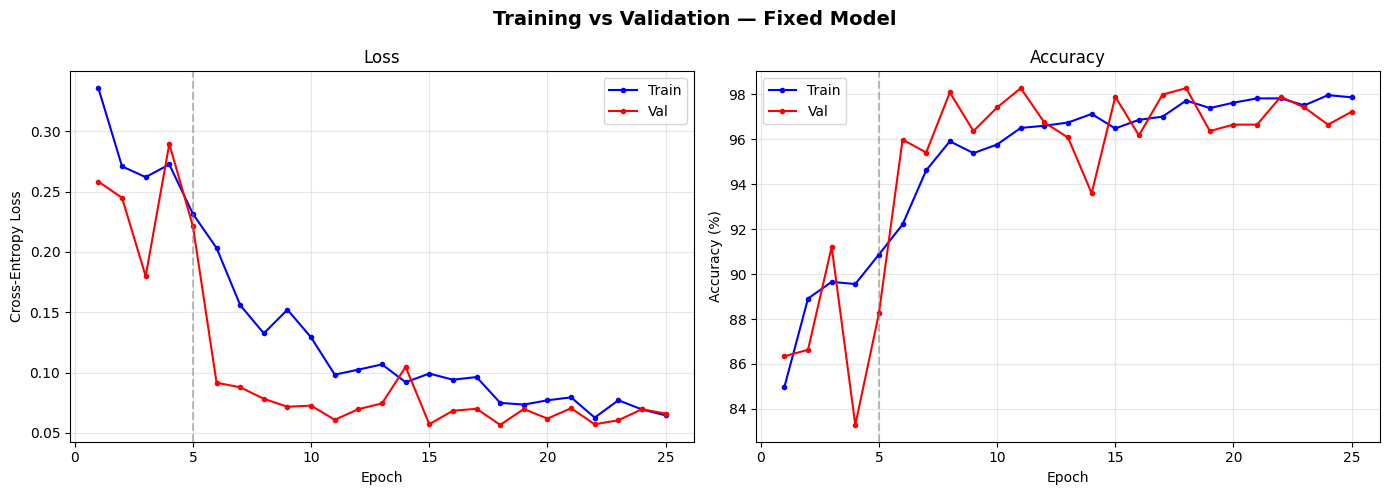

In [13]:
#TRAINING CURVES 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Validation — Fixed Model', fontsize=14, fontweight='bold')

ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[0].plot(ep, history['val_loss'],   'r-o', markersize=3, label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Phase switch')

axes[1].plot(ep, history['train_acc'], 'b-o', markersize=3, label='Train')
axes[1].plot(ep, history['val_acc'],   'r-o', markersize=3, label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Phase switch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# EVALUATE ON TEST SET 

model.load_state_dict(torch.load('checkpoints/best_model.pth', map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        output = model(data)
        probs  = F.softmax(output, dim=1)[:, 1]   # prob of PNEUMONIA
        preds  = output.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Metrics
test_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
auc      = roc_auc_score(all_labels, all_probs)

print('=' * 52)
print('           TEST SET RESULTS')
print('=' * 52)
print(f'  Accuracy : {test_acc:.2f}%')
print(f'  AUC-ROC  : {auc:.4f}')
print('=' * 52)
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

           TEST SET RESULTS
  Accuracy : 91.99%
  AUC-ROC  : 0.9847

              precision    recall  f1-score   support

      NORMAL       0.99      0.79      0.88       234
   PNEUMONIA       0.89      0.99      0.94       390

    accuracy                           0.92       624
   macro avg       0.94      0.89      0.91       624
weighted avg       0.93      0.92      0.92       624



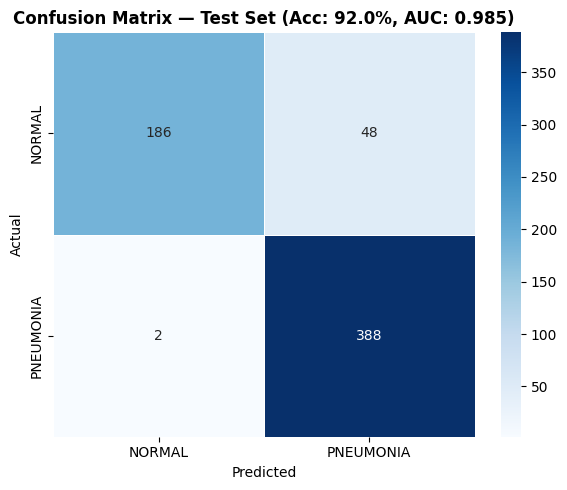

In [15]:
# CONFUSION MATRIX 

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — Test Set (Acc: {test_acc:.1f}%, AUC: {auc:.3f})',
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()